In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
electric_vehicles= pd.read_csv('electric_vehicles_spec_2025.csv.csv')

In [6]:
electric_vehicles.head()

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,Abarth,500e Convertible,155,37.8,Lithium-ion,192.0,235.0,156,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1904/Abarth-500e-C...
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,192.0,235.0,149,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1903/Abarth-500e-H...
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,102.0,345.0,158,280,5.9,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3057/Abarth-600e-S...
3,Abarth,600e Turismo,200,50.8,Lithium-ion,102.0,345.0,158,280,6.2,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3056/Abarth-600e-T...
4,Aiways,U5,150,60.0,Lithium-ion,NaN,310.0,156,315,7.5,...,NaN,496,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5


In [11]:
electric_vehicles.dtypes

brand                         object
model                         object
top_speed_kmh                  int64
battery_capacity_kWh         float64
battery_type                  object
number_of_cells              float64
torque_nm                    float64
efficiency_wh_per_km           int64
range_km                       int64
acceleration_0_100_s         float64
fast_charging_power_kw_dc    float64
fast_charge_port              object
towing_capacity_kg           float64
cargo_volume_l                object
seats                          int64
drivetrain                    object
segment                       object
length_mm                      int64
width_mm                       int64
height_mm                      int64
car_body_type                 object
source_url                    object
dtype: object

In [13]:
electric_vehicles_models['cargo_volume_l'].unique()

array(['185', '360', '496', '472', '400', '326', '502', '520', '535',
       '526', '511', '10 Banana Boxes', '514', '350', '405', '470', '490',
       '570', '500', '525', '440', '345', '308', '552', '235', '385',
       '540', '793', '775', '1050', '310', '460', '380', '510', '603',
       '989', '390', '620', '467', '361', '572', '536', '519', '523', nan,
       '672', '228', '333', '354', '432', '503', '438', '280', '480',
       '401', '338', '466', '505', '355', '550', '839', '435', '475',
       '309', '210', '522', '316', '611', '509', '456', '410', '249',
       '363', '479', '453', '448', '151', '270', '31 Banana Boxes', '340',
       '495', '430', '645', '13 Banana Boxes', '828', '551', '1410',
       '1030', '555', '1390', '990', '300', '200', '579', '265', '386',
       '450', '468', '415', '819', '352', '516', '267', '434', '588',
       '412', '608', '471', '348', '407', '484', '446', '366', '367',
       '420', '950', '545', '585', '313', '323', '370', '630', '441',
   

In [12]:
electric_vehicles_models= electric_vehicles.drop(
    ['model', 'battery_type', 'segment', 'source_url'],
    axis=1
)

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Información básica
print(electric_vehicles_models.shape)
print(electric_vehicles_models.info())

# Nulos
print("\nValores nulos:")
print(electric_vehicles_models.isnull().sum()[electric_vehicles_models.isnull().sum() > 0])

# Duplicados
print(f"\nDuplicados: {electric_vehicles_models.duplicated().sum()}")
electric_vehicles_models = electric_vehicles_models.drop_duplicates()

#

(478, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand                      478 non-null    object 
 1   top_speed_kmh              478 non-null    int64  
 2   battery_capacity_kWh       478 non-null    float64
 3   number_of_cells            276 non-null    float64
 4   torque_nm                  471 non-null    float64
 5   efficiency_wh_per_km       478 non-null    int64  
 6   range_km                   478 non-null    int64  
 7   acceleration_0_100_s       478 non-null    float64
 8   fast_charging_power_kw_dc  477 non-null    float64
 9   fast_charge_port           477 non-null    object 
 10  towing_capacity_kg         452 non-null    float64
 11  cargo_volume_l             477 non-null    object 
 12  seats                      478 non-null    int64  
 13  drivetrain                 478 non-null 

In [16]:
# Eliminar columnas poco útiles
cols_drop = ['model', 'source_url']

for col in cols_drop:
    if col in electric_vehicles_models.columns:
        electric_vehicles_models.drop(col, axis=1, inplace=True)

# Revisar valores negativos en variables que no deberían ser negativas

cols_no_negativas = [
    'range_km',
    'battery_capacity_kwh',
    'torque_nm',
    'number_of_cells',
    'cargo_volume_l',
    'towing_capacity_kg',
    'top_speed_kmh',
    'acceleration_0_100_s',
    'fast_charging_power_kw_dc'
]

for col in cols_no_negativas:
    if col in electric_vehicles_models.columns:
        negativos = (pd.to_numeric(electric_vehicles_models[col], errors='coerce') < 0).sum()
        print(f"{col}: {negativos} valores negativos")

# Convertir cargo_volume_l a numérica si es necesario
if 'cargo_volume_l' in electric_vehicles_models.columns:
    electric_vehicles_models['cargo_volume_l'] = (
        electric_vehicles_models['cargo_volume_l']
        .astype(str)
        .str.replace(' Banana Boxes', '', regex=False)
    )

    electric_vehicles_models['cargo_volume_l'] = pd.to_numeric(
        electric_vehicles_models['cargo_volume_l'],
        errors='coerce'
    )


range_km: 0 valores negativos
torque_nm: 0 valores negativos
number_of_cells: 0 valores negativos
cargo_volume_l: 0 valores negativos
towing_capacity_kg: 0 valores negativos
top_speed_kmh: 0 valores negativos
acceleration_0_100_s: 0 valores negativos
fast_charging_power_kw_dc: 0 valores negativos


Calcular la variable de correlación de Pearson 

                           top_speed_kmh  battery_capacity_kWh  \
top_speed_kmh                   1.000000              0.706778   
battery_capacity_kWh            0.706778              1.000000   
number_of_cells                 0.361568              0.214346   
torque_nm                       0.806282              0.758170   
efficiency_wh_per_km            0.163473              0.377056   
range_km                        0.730666              0.877674   
acceleration_0_100_s           -0.823494             -0.645078   
fast_charging_power_kw_dc       0.771899              0.723905   
towing_capacity_kg              0.220319              0.441798   
cargo_volume_l                 -0.173894              0.084698   
seats                          -0.321192              0.007085   
length_mm                       0.438266              0.684354   
width_mm                        0.529649              0.725448   
height_mm                      -0.467012             -0.060293   

         

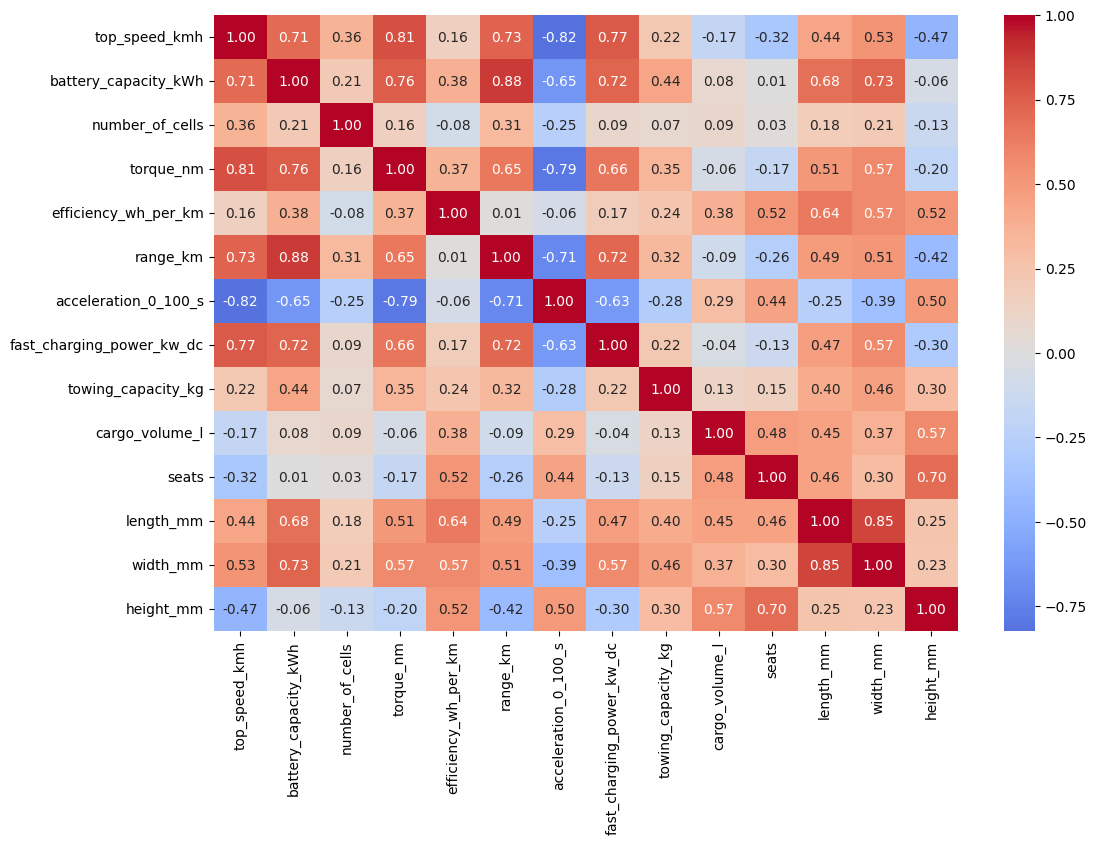

In [18]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Variables numéricas
df_num = electric_vehicles_models.select_dtypes(include=np.number)

# Matriz de correlación de Pearson
corr = df_num.corr(method='pearson')

# Mostrar matriz
print(corr)

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.show()

In [21]:
import numpy as np
import pandas as pd

variables = [
    'range_km',
    "battery_capacity_kWh",
    "efficiency_wh_per_km",
    "torque_nm",
    "width_mm",
    "seats",
    "cargo_volume_l"
]


df_model = electric_vehicles_models[variables].copy()

# Duplicados
print("Duplicados:", df_model.duplicated().sum())
df_model = df_model.drop_duplicates()

# Nulos
print("\nNulos antes:")
print(df_model.isnull().sum())

# Reemplazar valores imposibles por NaN
for col in df_model.columns:
    if col != 'range_km':
        df_model.loc[df_model[col] <= 0, col] = np.nan

df_model.loc[df_model['range_km'] <= 0, 'range_km'] = np.nan

# Imputar con mediana
for col in df_model.columns:
    df_model[col] = df_model[col].fillna(df_model[col].median())

print("\nNulos después:")
print(df_model.isnull().sum())



Duplicados: 17

Nulos antes:
range_km                0
battery_capacity_kWh    0
efficiency_wh_per_km    0
torque_nm               7
width_mm                0
seats                   0
cargo_volume_l          1
dtype: int64

Nulos después:
range_km                0
battery_capacity_kWh    0
efficiency_wh_per_km    0
torque_nm               0
width_mm                0
seats                   0
cargo_volume_l          0
dtype: int64


R²: 0.9791870341253448
MAE: 11.626566733083417
RMSE: 15.440262540507387


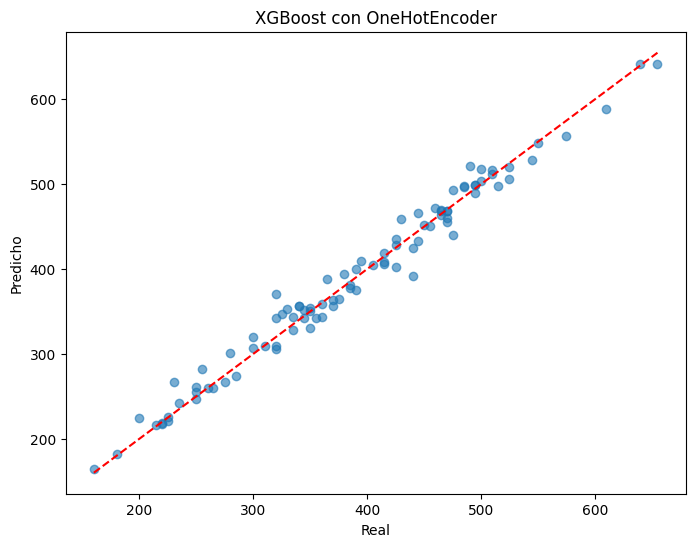

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

#Una vez se han seleccionado las varibles numéricas y categóricas, se procede a preparar el dataset del modelo

num_vars = [
    "range_km",
    "battery_capacity_kWh",
    "efficiency_wh_per_km",
    "torque_nm",
    "width_mm",
    "seats",
    "cargo_volume_l"
]

cat_vars = [
    "brand",
    "drivetrain",
    "car_body_type",
    "fast_charge_port"
]


df_model = electric_vehicles_models[num_vars + cat_vars].copy()
df_model = df_model.drop_duplicates()


for col in num_vars:
    df_model.loc[df_model[col] <= 0, col] = np.nan

df_model[num_vars] = df_model[num_vars].fillna(df_model[num_vars].median())
df_model[cat_vars] = df_model[cat_vars].fillna(df_model[cat_vars].mode().iloc[0])



ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

encoded = ohe.fit_transform(df_model[cat_vars])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cat_vars),
    index=df_model.index
)

df_model = pd.concat([df_model[num_vars], encoded_df], axis=1)



# 5FEATURES / TARGET


X = df_model.drop("range_km", axis=1)
y = df_model["range_km"]


# =========================
# 6. SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=15
)


# =========================
# 7. MODELO
# =========================

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=15
)

model.fit(X_train, y_train)


# =========================
# 8. PREDICCIÓN
# =========================

y_pred = model.predict(X_test)


# =========================
# 9. MÉTRICAS
# =========================

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


# =========================
# 10. GRÁFICO
# =========================

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("XGBoost con OneHotEncoder")
plt.show()

<Figure size 1000x600 with 0 Axes>

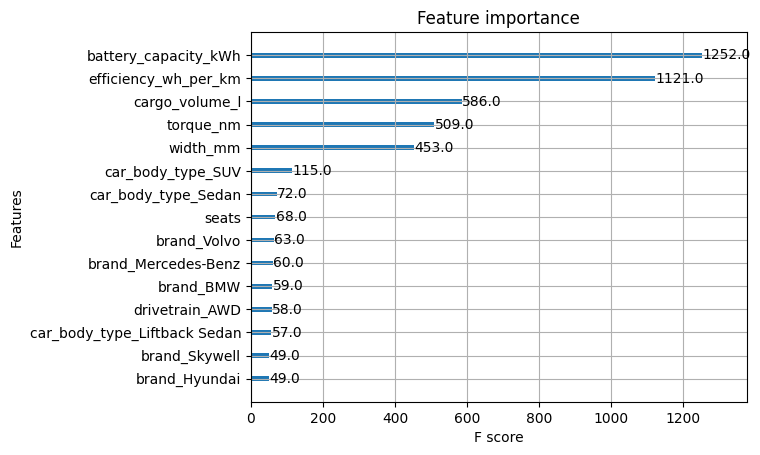

In [24]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_importance(model, max_num_features=15)
plt.show()